# METU Ceng 502 Spring'26
### Mete Enes Yilmaz
### 2786523
## Reproduction of Table 3: GraphSAGE vs. CopresheafSAGE on MUTAG

**Paper:** Mustafa Hajij et al., *Copresheaf Topological Neural Networks: A Generalized Deep Learning Framework*, NeurIPS 2025.
- **arXiv:** https://arxiv.org/abs/2505.21251
- **OpenReview:** https://openreview.net/forum?id=3G56xClPYg

## Reproduction target
Two GraphSAGE-related rows of **Table 3**:

| Model | Paper test accuracy |
|---|---:|
| GraphSAGE | 0.689 ± 0.022 |
| CopresheafSAGE | 0.732 ± 0.029 |

## Paper settings
- MUTAG: 188 molecular graphs, 7 node features, 2 classes
- 80% train / 20% test
- Two graph-convolution layers
- Hidden dimension 32
- Global mean pooling and a linear classifier
- Adam, learning rate 0.01, batch size 16
- Negative log-likelihood loss
- 50 epochs and five runs

## Note for Grader:
- No open / offical source code observed to be published by authors by June 2026
- The paper does not specify the exact split seeds, initialization, the value/trainability of epsilon, or every projection detail. I have stated those assumptions by the keyword "NOTE_TO_GRADER".
- Google Colab used for its GPU computation source. A GPU is optional because MUTAG is small.


## Install Dependencies

In [ ]:
%pip install -q torch_geometric scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.2 MB/s eta 0:00:00


In [ ]:
import os
import sys
import json
import random
import platform
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F

import torch_geometric
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.utils import scatter

from scipy import stats

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass(frozen=True)
class Config:
    dataset_name: str = "MUTAG"
    data_root: str = "./data/TUDataset"
    hidden_dim: int = 32
    batch_size: int = 16
    learning_rate: float = 0.01
    epochs: int = 50
    train_ratio: float = 0.80
    seeds: tuple = (0, 1, 2, 3, 4)
    # NOTE_TO_GRADER : The paper writes (1 + epsilon)h_i but does not specify epsilon.
    epsilon: float = 0.0
    num_workers: int = 0
    output_dir: str = "./mutag_reproduction_outputs"


cfg = Config()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

# Print configs
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("\nConfiguration:")
print(json.dumps(asdict(cfg), indent=2, default=list))

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
PyG: 2.8.0
Device: cuda
GPU: Tesla T4

Configuration:
{
  "dataset_name": "MUTAG",
  "data_root": "./data/TUDataset",
  "hidden_dim": 32,
  "batch_size": 16,
  "learning_rate": 0.01,
  "epochs": 50,
  "train_ratio": 0.8,
  "seeds": [
    0,
    1,
    2,
    3,
    4
  ],
  "epsilon": 0.0,
  "num_workers": 0,
  "output_dir": "./mutag_reproduction_outputs"
}


## Determinism and paired 80/20 splits

In [ ]:
def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def make_random_split(dataset, seed: int, train_ratio: float):
    # NOTE_TO_GRADER : Paper-aligned random 80/20 split, reused by both models
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(len(dataset), generator=generator)
    n_train = int(train_ratio * len(dataset))
    return permutation[:n_train].tolist(), permutation[n_train:].tolist()


def class_counts(dataset, indices):
    labels = [int(dataset[i].y.item()) for i in indices]
    unique, counts = np.unique(labels, return_counts=True)
    return {int(k): int(v) for k, v in zip(unique, counts)}

## Load and inspect MUTAG

In [ ]:
dataset = TUDataset(root=cfg.data_root, name=cfg.dataset_name)

assert len(dataset) == 188, f"Expected 188 graphs, found {len(dataset)}"
assert dataset.num_node_features == 7, dataset.num_node_features
assert dataset.num_classes == 2, dataset.num_classes

all_labels = np.array([int(data.y.item()) for data in dataset])
unique, counts = np.unique(all_labels, return_counts=True)

print(dataset)
print("Number of graphs:", len(dataset))
print("Node features:", dataset.num_node_features)
print("Classes:", dataset.num_classes)
print("Full-dataset class counts:", dict(zip(unique.tolist(), counts.tolist())))
print("Example graph:", dataset[0])

MUTAG(188)
Number of graphs: 188
Node features: 7
Classes: 2
Full-dataset class counts: {0: 63, 1: 125}
Example graph: Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])


Processing...
Done!


In [ ]:
class MeanSAGEConv(nn.Module):

    def __init__(self, in_channels: int, out_channels: int, epsilon: float = 0.0):
        super().__init__()
        self.lin_root = nn.Linear(in_channels, out_channels, bias=True)
        self.lin_neigh = nn.Linear(in_channels, out_channels, bias=False)
        self.register_buffer("epsilon", torch.tensor(float(epsilon)))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        neighbor_mean = scatter(
            x[src], dst, dim=0, dim_size=x.size(0), reduce="mean"
        )
        return (
            self.lin_root((1.0 + self.epsilon) * x)
            + self.lin_neigh(neighbor_mean)
        )


class CopresheafSAGEConv(nn.Module):

    def __init__(self, in_channels: int, out_channels: int, epsilon: float = 0.0):
        super().__init__()
        self.delta_map = nn.Linear(2 * in_channels, in_channels)
        self.lin_root = nn.Linear(in_channels, out_channels, bias=True)
        self.lin_neigh = nn.Linear(in_channels, out_channels, bias=False)
        self.register_buffer("epsilon", torch.tensor(float(epsilon)))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        h_j = x[src]
        h_i = x[dst]

        edge_features = torch.cat([h_i, h_j], dim=-1)
        delta_ij = torch.tanh(self.delta_map(edge_features))
        transported_messages = (1.0 + delta_ij) * h_j

        transported_mean = scatter(
            transported_messages,
            dst,
            dim=0,
            dim_size=x.size(0),
            reduce="mean",
        )

        return (
            self.lin_root((1.0 + self.epsilon) * x)
            + self.lin_neigh(transported_mean)
        )


class GraphClassifier(nn.Module):
    def __init__(
        self,
        model_type: str,
        in_dim: int,
        hidden_dim: int,
        num_classes: int,
        epsilon: float = 0.0,
    ):
        super().__init__()

        if model_type == "graphsage":
            conv_cls = MeanSAGEConv
        elif model_type == "copresheaf_sage":
            conv_cls = CopresheafSAGEConv
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        self.conv1 = conv_cls(in_dim, hidden_dim, epsilon)
        self.conv2 = conv_cls(hidden_dim, hidden_dim, epsilon)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = x.float()
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        graph_embedding = global_mean_pool(x, batch)
        logits = self.classifier(graph_embedding)
        return F.log_softmax(logits, dim=-1)


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


baseline_example = GraphClassifier(
    "graphsage", dataset.num_node_features, cfg.hidden_dim,
    dataset.num_classes, cfg.epsilon
)
copresheaf_example = GraphClassifier(
    "copresheaf_sage", dataset.num_node_features, cfg.hidden_dim,
    dataset.num_classes, cfg.epsilon
)

print("GraphSAGE parameters:", count_trainable_parameters(baseline_example))
print("CopresheafSAGE parameters:", count_trainable_parameters(copresheaf_example))
print(
    "Additional parameters:",
    count_trainable_parameters(copresheaf_example)
    - count_trainable_parameters(baseline_example),
)

GraphSAGE parameters: 2626
CopresheafSAGE parameters: 4811
Additional parameters: 2185


## Training and evaluation protocol

NOTE_TO_GRADER : The test set is evaluated **only after epoch 50**. We do not report the maximum test accuracy across epochs, because selecting an epoch using the test set is test leakage.

In [ ]:
def train_one_epoch(model, loader, optimizer) -> float:
    model.train()
    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        log_probabilities = model(batch.x, batch.edge_index, batch.batch)
        loss = F.nll_loss(log_probabilities, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * batch.num_graphs
        total_graphs += batch.num_graphs

    return total_loss / total_graphs


@torch.no_grad()
def evaluate_accuracy(model, loader) -> float:
    model.eval()
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)
        output = model(batch.x, batch.edge_index, batch.batch)
        predictions = output.argmax(dim=-1)
        correct += int((predictions == batch.y).sum().item())
        total += batch.num_graphs

    return correct / total


def run_one_seed(model_name, model_type, seed, train_idx, test_idx):
    set_seed(seed)

    train_dataset = dataset[train_idx]
    test_dataset = dataset[test_idx]
    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.batch_size,
        shuffle=True,
        generator=generator,
        num_workers=cfg.num_workers,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
    )

    model = GraphClassifier(
        model_type=model_type,
        in_dim=dataset.num_node_features,
        hidden_dim=cfg.hidden_dim,
        num_classes=dataset.num_classes,
        epsilon=cfg.epsilon,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
    loss_history = []

    for epoch in range(1, cfg.epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        loss_history.append(train_loss)

        if epoch in {1, 10, 20, 30, 40, cfg.epochs}:
            print(
                f"{model_name:17s} | seed={seed} | "
                f"epoch={epoch:02d}/{cfg.epochs} | train NLL={train_loss:.4f}"
            )

    final_test_accuracy = evaluate_accuracy(model, test_loader)

    return {
        "model": model_name,
        "seed": seed,
        "test_accuracy": final_test_accuracy,
        "final_train_nll": loss_history[-1],
        "parameter_count": count_trainable_parameters(model),
        "train_size": len(train_idx),
        "test_size": len(test_idx),
        "train_class_counts": json.dumps(class_counts(dataset, train_idx)),
        "test_class_counts": json.dumps(class_counts(dataset, test_idx)),
        "loss_history": loss_history,
    }

## Run five paired seeds

In [ ]:
models_to_run = [
    ("GraphSAGE", "graphsage"),
    ("CopresheafSAGE", "copresheaf_sage"),
]

records = []
histories = {}

for seed in cfg.seeds:
    train_idx, test_idx = make_random_split(dataset, seed, cfg.train_ratio)

    print("\n" + "=" * 78)
    print(
        f"Seed {seed} | train={len(train_idx)} {class_counts(dataset, train_idx)} | "
        f"test={len(test_idx)} {class_counts(dataset, test_idx)}"
    )
    print("=" * 78)

    for model_name, model_type in models_to_run:
        result = run_one_seed(
            model_name, model_type, seed, train_idx, test_idx
        )
        histories[(model_name, seed)] = result.pop("loss_history")
        records.append(result)
        print(
            f"FINAL: {model_name:17s} | seed={seed} | "
            f"test accuracy={result['test_accuracy']:.4f}"
        )

results_df = pd.DataFrame(records)
display(results_df.sort_values(["seed", "model"]))


Seed 0 | train=150 {0: 50, 1: 100} | test=38 {0: 13, 1: 25}
GraphSAGE         | seed=0 | epoch=01/50 | train NLL=0.6806
GraphSAGE         | seed=0 | epoch=10/50 | train NLL=0.5522
GraphSAGE         | seed=0 | epoch=20/50 | train NLL=0.5346
GraphSAGE         | seed=0 | epoch=30/50 | train NLL=0.5035
GraphSAGE         | seed=0 | epoch=40/50 | train NLL=0.4979
GraphSAGE         | seed=0 | epoch=50/50 | train NLL=0.4892
FINAL: GraphSAGE         | seed=0 | test accuracy=0.8158
CopresheafSAGE    | seed=0 | epoch=01/50 | train NLL=0.6465
CopresheafSAGE    | seed=0 | epoch=10/50 | train NLL=0.5218
CopresheafSAGE    | seed=0 | epoch=20/50 | train NLL=0.5044
CopresheafSAGE    | seed=0 | epoch=30/50 | train NLL=0.4685
CopresheafSAGE    | seed=0 | epoch=40/50 | train NLL=0.4635
CopresheafSAGE    | seed=0 | epoch=50/50 | train NLL=0.4565
FINAL: CopresheafSAGE    | seed=0 | test accuracy=0.7895

Seed 1 | train=150 {0: 46, 1: 104} | test=38 {0: 17, 1: 21}
GraphSAGE         | seed=1 | epoch=01/50 | t

,model,seed,test_accuracy,final_train_nll,parameter_count,train_size,test_size,train_class_counts,test_class_counts
1,CopresheafSAGE,0,0.789474,0.456535,4811,150,38,"{""0"": 50, ""1"": 100}","{""0"": 13, ""1"": 25}"
0,GraphSAGE,0,0.815789,0.489183,2626,150,38,"{""0"": 50, ""1"": 100}","{""0"": 13, ""1"": 25}"
3,CopresheafSAGE,1,0.710526,0.383598,4811,150,38,"{""0"": 46, ""1"": 104}","{""0"": 17, ""1"": 21}"
2,GraphSAGE,1,0.684211,0.454877,2626,150,38,"{""0"": 46, ""1"": 104}","{""0"": 17, ""1"": 21}"
5,CopresheafSAGE,2,0.763158,0.433659,4811,150,38,"{""0"": 50, ""1"": 100}","{""0"": 13, ""1"": 25}"
4,GraphSAGE,2,0.710526,0.444132,2626,150,38,"{""0"": 50, ""1"": 100}","{""0"": 13, ""1"": 25}"
7,CopresheafSAGE,3,0.684211,0.355456,4811,150,38,"{""0"": 48, ""1"": 102}","{""0"": 15, ""1"": 23}"
6,GraphSAGE,3,0.657895,0.403986,2626,150,38,"{""0"": 48, ""1"": 102}","{""0"": 15, ""1"": 23}"
9,CopresheafSAGE,4,0.684211,0.421415,4811,150,38,"{""0"": 50, ""1"": 100}","{""0"": 13, ""1"": 25}"
8,GraphSAGE,4,0.710526,0.436481,2626,150,38,"{""0"": 50, ""1"": 100}","{""0"": 13, ""1"": 25}"


## Summary / Comparison

In [ ]:
summary_df = (
    results_df
    .groupby("model", as_index=False)
    .agg(
        mean_test_accuracy=("test_accuracy", "mean"),
        std_test_accuracy=("test_accuracy", "std"),
        min_test_accuracy=("test_accuracy", "min"),
        max_test_accuracy=("test_accuracy", "max"),
        parameter_count=("parameter_count", "first"),
    )
)

paper_results = pd.DataFrame({
    "model": ["GraphSAGE", "CopresheafSAGE"],
    "paper_mean": [0.689, 0.732],
    "paper_std": [0.022, 0.029],
})

comparison_df = summary_df.merge(paper_results, on="model", how="left")
comparison_df["absolute_mean_error"] = (
    comparison_df["mean_test_accuracy"] - comparison_df["paper_mean"]
).abs()
comparison_df["ours_mean_std"] = comparison_df.apply(
    lambda row: f"{row['mean_test_accuracy']:.3f} ± {row['std_test_accuracy']:.3f}",
    axis=1,
)
comparison_df["paper_mean_std"] = comparison_df.apply(
    lambda row: f"{row['paper_mean']:.3f} ± {row['paper_std']:.3f}",
    axis=1,
)

paired_df = (
    results_df
    .pivot(index="seed", columns="model", values="test_accuracy")
    .reset_index()
)
paired_df["Copresheaf_minus_GraphSAGE"] = (
    paired_df["CopresheafSAGE"] - paired_df["GraphSAGE"]
)

differences = paired_df["Copresheaf_minus_GraphSAGE"].to_numpy()
mean_difference = float(differences.mean())
std_difference = float(differences.std(ddof=1))
sem_difference = stats.sem(differences)
ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=len(differences) - 1,
    loc=mean_difference,
    scale=sem_difference,
)
paired_t = stats.ttest_rel(
    paired_df["CopresheafSAGE"], paired_df["GraphSAGE"]
)

print("Paper comparison:")
display(comparison_df[[
    "model", "paper_mean_std", "ours_mean_std",
    "absolute_mean_error", "parameter_count"
]])

print("\nPaired seed-level comparison:")
display(paired_df)

print(f"\nMean paired improvement: {100 * mean_difference:+.2f} percentage points")
print(f"SD of paired improvement: {100 * std_difference:.2f} percentage points")
print(
    "95% t-interval: "
    f"[{100 * ci_low:+.2f}, {100 * ci_high:+.2f}] percentage points"
)
print(f"Paired t-test p-value: {paired_t.pvalue:.4f}")
print(
    "Interpret inferential statistics cautiously: five runs give low power, "
    "and the paper does not disclose the exact split seeds."
)

Paper comparison:


,model,paper_mean_std,ours_mean_std,absolute_mean_error,parameter_count
0,CopresheafSAGE,0.732 ± 0.029,0.726 ± 0.048,0.005684,4811
1,GraphSAGE,0.689 ± 0.022,0.716 ± 0.060,0.026789,2626



Paired seed-level comparison:


model,seed,CopresheafSAGE,GraphSAGE,Copresheaf_minus_GraphSAGE
0,0,0.789474,0.815789,-0.026316
1,1,0.710526,0.684211,0.026316
2,2,0.763158,0.710526,0.052632
3,3,0.684211,0.657895,0.026316
4,4,0.684211,0.710526,-0.026316



Mean paired improvement: +1.05 percentage points
SD of paired improvement: 3.53 percentage points
95% t-interval: [-3.33, +5.44] percentage points
Paired t-test p-value: 0.5415
Interpret inferential statistics cautiously: five runs give low power, and the paper does not disclose the exact split seeds.


## Visualizations

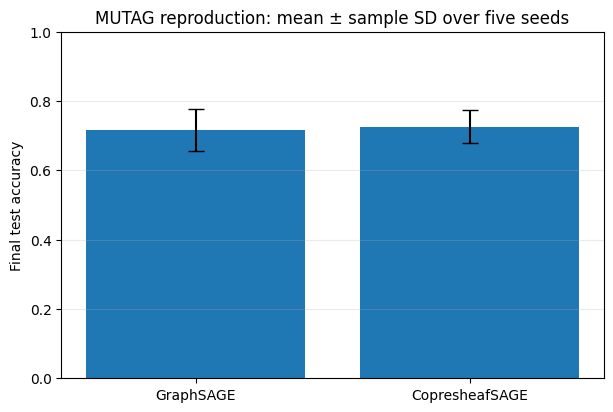

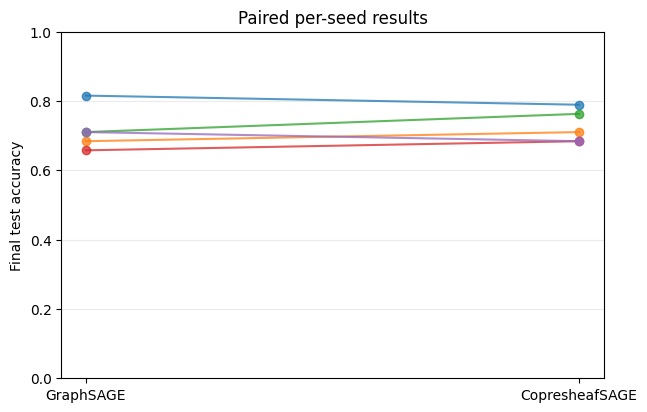

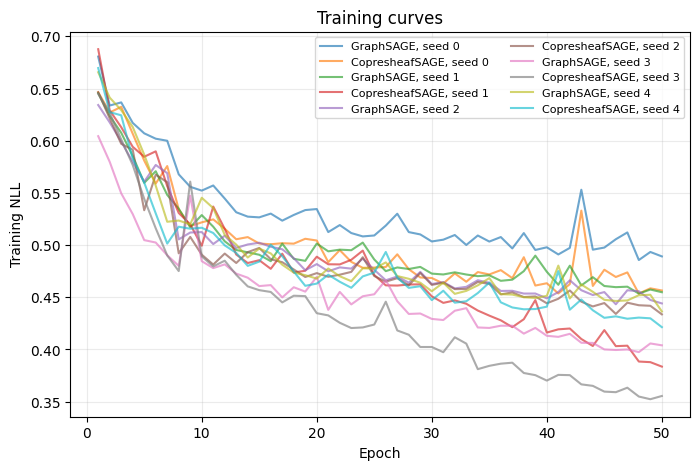

In [ ]:
plot_order = ["GraphSAGE", "CopresheafSAGE"]
plot_df = summary_df.set_index("model").loc[plot_order].reset_index()

plt.figure(figsize=(7, 4.5))
plt.bar(
    plot_df["model"],
    plot_df["mean_test_accuracy"],
    yerr=plot_df["std_test_accuracy"],
    capsize=6,
)
plt.ylabel("Final test accuracy")
plt.title("MUTAG reproduction: mean ± sample SD over five seeds")
plt.ylim(0.0, 1.0)
plt.grid(axis="y", alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4.5))
for _, row in paired_df.iterrows():
    plt.plot(
        ["GraphSAGE", "CopresheafSAGE"],
        [row["GraphSAGE"], row["CopresheafSAGE"]],
        marker="o",
        alpha=0.75,
    )
plt.ylabel("Final test accuracy")
plt.title("Paired per-seed results")
plt.ylim(0.0, 1.0)
plt.grid(axis="y", alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
for (model_name, seed), losses in histories.items():
    plt.plot(
        range(1, len(losses) + 1),
        losses,
        label=f"{model_name}, seed {seed}",
        alpha=0.65,
    )
plt.xlabel("Epoch")
plt.ylabel("Training NLL")
plt.title("Training curves")
plt.legend(fontsize=8, ncol=2)
plt.grid(alpha=0.25)
plt.show()